In [19]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from algorithm_evaluation import evaluate


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Testing Section

In [59]:
df = evaluate(
            'algorithm_evaluation/example-graphs/bnlearn/medium-networks/alarm.bif',
            confounder_ratio_range=(0.6, 1.0),
            n_simulations=10,
            seed=42,
            verbose=True,
            experiment_set_size=100,
            theta_config=  {
                'CF_fraction': 0.5,
                'W_sizes': [1,2,3],
                'Z_sizes': [3],
                'intervention_outcome_distances': [2],
            },
            experiment_config={
                'CF_fraction': 0.7,
                'W_sizes': [2],
                'Z_sizes': [5],
            },
            save_graphs="graphs.json"
        )

Graph: alarm.bif, |V|=37, |A|=100, ratio_range=(0.6, 1.0)
  u/v=0.97, sim 10/10: pruned 22.0%


In [62]:
df[df['sim']==7]

,graph,n_vars,u_v_ratio,sim,n_confounders,n_districts,query,query_is_cf,min_intervention_outcome_dist,n_R_theta,n_R_theta_star,n_experiments,n_cf_experiments,fraction_cf,n_useless,n_useful,fraction_pruned,id_pruned,blocked_pruned
7,alarm.bif,37,0.72973,7,27,11,"Y={'SHUNT'}, X={'INTUBATION', 'PULMEMBOLUS'}",False,1,1,1,100,69,0.69,51,49,0.51,22,29


/home/tobi/research/optimal-experiments-for-partial-ID/algorithm_evaluation/visualize.py:142: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


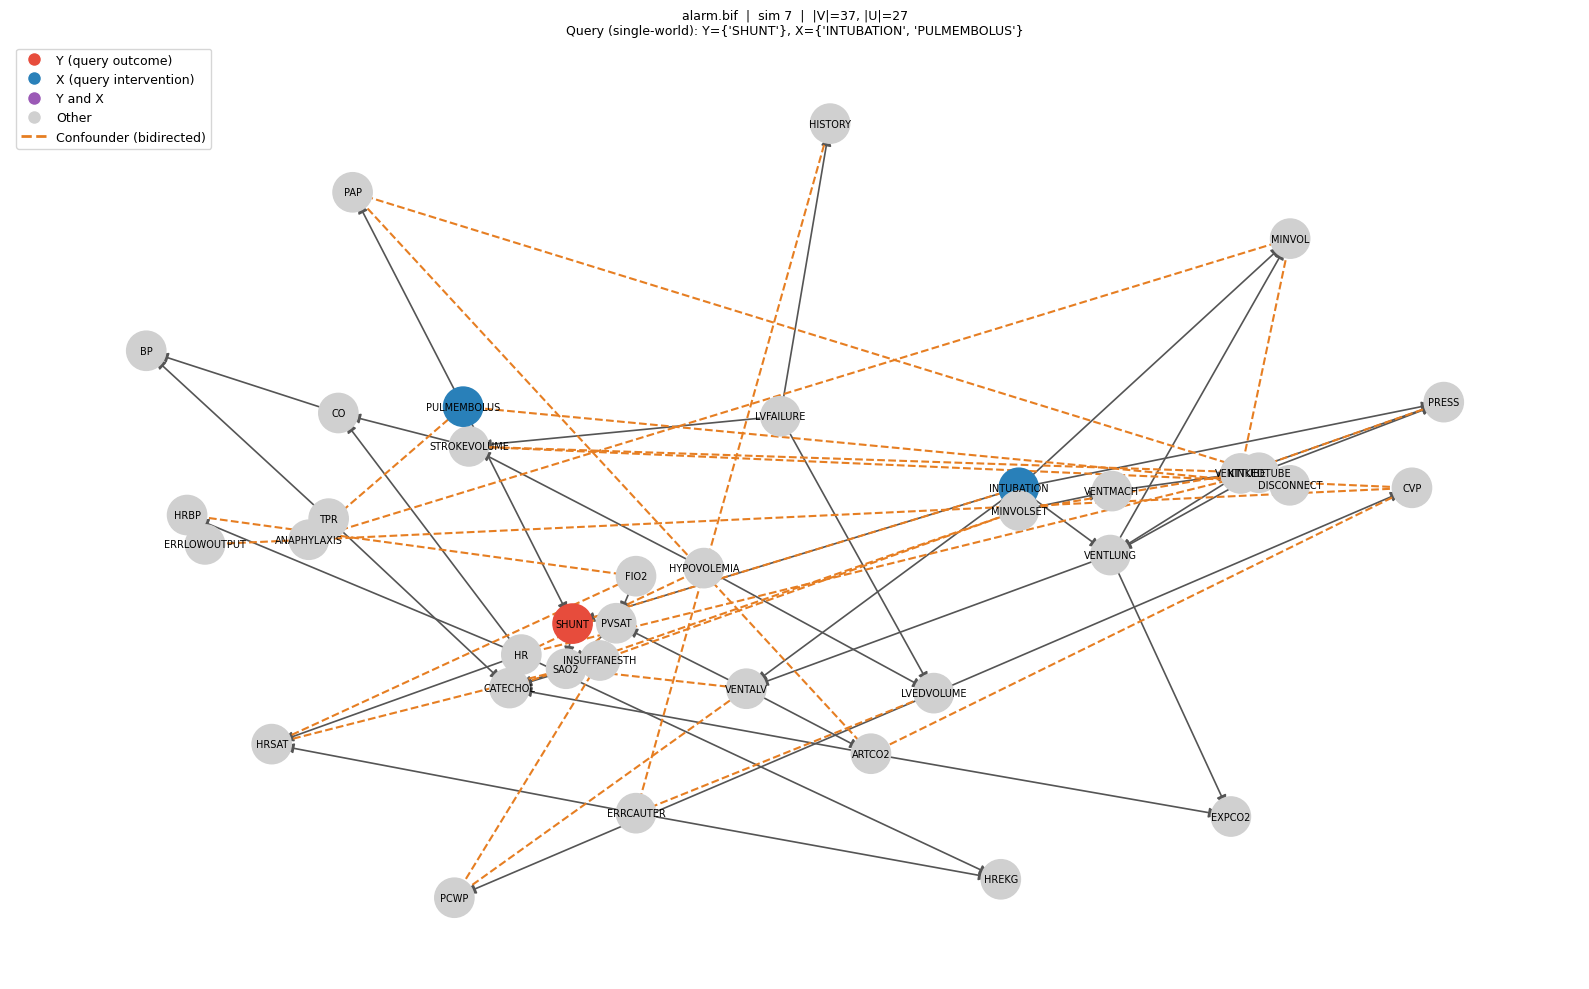

Simulation: alarm.bif  sim=7
|V|=37, |U|=27, |A|=100
Query: Y={'SHUNT'}, X={'INTUBATION', 'PULMEMBOLUS'}

--- Useful (49) ---
  [  1] (CF) W={'EXPCO2', 'CO'}, Z={'CATECHOL', 'INTUBATION', 'INSUFFANESTH', 'VENTMACH', 'HR'}; W={'VENTALV', 'CO'}, Z={'VENTLUNG', 'PVSAT', 'INSUFFANESTH', 'MINVOLSET', 'HR'}
  [  4] (CF) W={'HRBP', 'CATECHOL'}, Z={'VENTALV', 'ANAPHYLAXIS', 'VENTMACH', 'VENTTUBE', 'HR'}; W={'SAO2', 'CATECHOL'}, Z={'VENTALV', 'ANAPHYLAXIS', 'INSUFFANESTH', 'VENTMACH', 'VENTTUBE'}
  [ 15] (CF) W={'HYPOVOLEMIA', 'CO'}, Z={'VENTALV', 'SAO2', 'VENTTUBE', 'KINKEDTUBE', 'FIO2'}; W={'BP', 'CO'}, Z={'VENTLUNG', 'SAO2', 'TPR', 'PULMEMBOLUS', 'LVFAILURE'}
  [ 16] (CF) W={'VENTALV', 'HRSAT'}, Z={'CATECHOL', 'TPR', 'ANAPHYLAXIS', 'VENTTUBE', 'KINKEDTUBE'}; W={'VENTALV', 'HREKG'}, Z={'SAO2', 'CATECHOL', 'DISCONNECT', 'SHUNT', 'VENTTUBE'}
  [ 22] (CF) W={'HRBP', 'VENTLUNG'}, Z={'VENTALV', 'PVSAT', 'INTUBATION', 'ANAPHYLAXIS', 'ERRLOWOUTPUT'}; W={'VENTLUNG', 'CO'}, Z={'PVSAT', 'INTUBATION', '

In [61]:
from algorithm_evaluation import plot_simulation, print_experiments
sim = 7
# Visualize the graph
plot_simulation("graphs.json", "alarm.bif", sim)

# Print experiments by pruning status
print_experiments("graphs.json", "alarm.bif", sim)

## Across `CF_fraction` values

In [28]:

small_networks= ['asia', 'sachs'] #path: small-networks/
medium_networks = ['alarm', 'barley', 'child', 'insurance', 'mildew', 'water'] # path: medium-networks/

all_graphs_paths = [f'small-networks/{graph}.bif' for graph in small_networks] + \
                   [f'medium-networks/{graph}.bif' for graph in medium_networks]
df = pd.DataFrame()

path_prefix= 'algorithm_evaluation/example-graphs/bnlearn/'

CF_fractions = [0, 0.25, 0.5, 0.75, 1]
for CF_fraction in CF_fractions:
    print(f"Evaluating CF_fraction: {CF_fraction}")
    for graph_path in all_graphs_paths:
        print(f"Evaluating graph: {graph_path}")
        df = pd.concat([df, evaluate(
            path_prefix + graph_path,
            confounder_ratio_range=(0.0, 1.0),
            n_simulations=5,
            seed=42,
            verbose=True,
            experiment_set_size=30,
            theta_config=  {
                'CF_fraction': 0.5,
                'W_sizes': [1, 2, 3, 4, 5],
                'Z_sizes': [1, 2, 3, 4, 5],
                'intervention_outcome_distances': [1,2,3,4,5],
            },
            experiment_config={
                'CF_fraction': CF_fraction,
                'W_sizes': [1, 2, 3, 4, 5],
                'Z_sizes': [1, 2, 3, 4, 5],
            }
        )], ignore_index=True)
df.to_csv('algorithm_evaluation/results/03_04__slide_across_CF_fraction.csv', index=False)

Evaluating CF_fraction: 0
Evaluating graph: small-networks/asia.bif
Graph: asia.bif, |V|=8, |A|=30, ratio_range=(0.0, 1.0)
Evaluating graph: small-networks/sachs.bif
Graph: sachs.bif, |V|=11, |A|=30, ratio_range=(0.0, 1.0)
Evaluating graph: medium-networks/alarm.bif
Graph: alarm.bif, |V|=37, |A|=30, ratio_range=(0.0, 1.0)
Evaluating graph: medium-networks/barley.bif
Graph: barley.bif, |V|=48, |A|=30, ratio_range=(0.0, 1.0)
Evaluating graph: medium-networks/child.bif
Graph: child.bif, |V|=20, |A|=30, ratio_range=(0.0, 1.0)
Evaluating graph: medium-networks/insurance.bif
Graph: insurance.bif, |V|=27, |A|=30, ratio_range=(0.0, 1.0)
Evaluating graph: medium-networks/mildew.bif
Graph: mildew.bif, |V|=35, |A|=30, ratio_range=(0.0, 1.0)
Evaluating graph: medium-networks/water.bif
Graph: water.bif, |V|=32, |A|=30, ratio_range=(0.0, 1.0)
Evaluating CF_fraction: 0.25
Evaluating graph: small-networks/asia.bif
Graph: asia.bif, |V|=8, |A|=30, ratio_range=(0.0, 1.0)
Evaluating graph: small-networks/

In [29]:
df = pd.read_csv('algorithm_evaluation/results/03_04__slide_across_CF_fraction.csv')

In [30]:
df['U_over_V'] = df['n_confounders'] / df['n_vars']
df['n_vars'].corr(df['U_over_V'])

# find average 'U_over_V' per graph
graph_col = 'graph_name' if 'graph_name' in df.columns else 'graph'
avg_U_over_V_per_graph = df.groupby(graph_col)['U_over_V'].mean().sort_values()
print(avg_U_over_V_per_graph)

graph
child.bif        0.406000
asia.bif         0.410000
barley.bif       0.428333
mildew.bif       0.485714
alarm.bif        0.497297
water.bif        0.508750
sachs.bif        0.549091
insurance.bif    0.611852
Name: U_over_V, dtype: float64


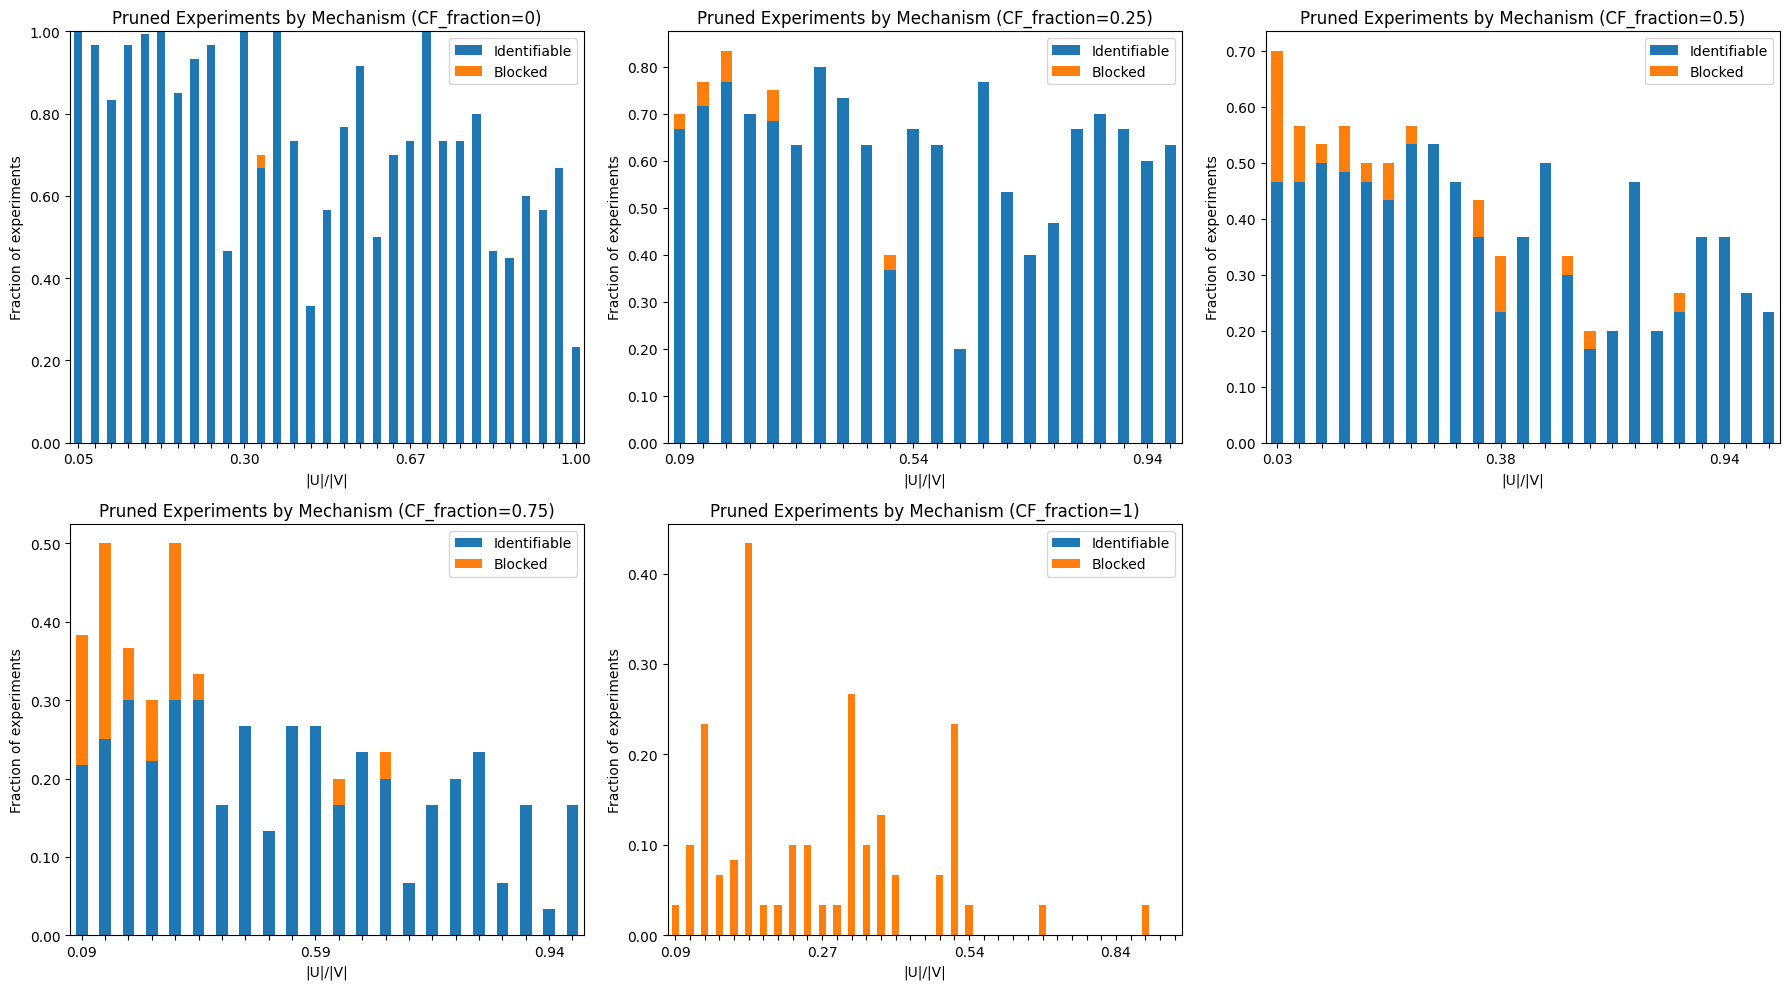

In [31]:
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter

n_rows=2
n_cols=3
# Build figure in this cell to ensure render
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
flat_axes = axes.flatten()

tol = 0.05
source_df = df if not df.empty else df_cf

CF_fractions = [0, 0.25, 0.5, 0.75, 1]

for idx, cf in enumerate(CF_fractions):
    ax = flat_axes[idx]

    mask = source_df["fraction_cf"].between(cf - tol, cf + tol)
    d = source_df.loc[mask]

    if d.empty:
        ax.set_title(f"Pruned Experiments by Mechanism (CF_fraction={cf})\nNo data")
        ax.set_xlabel("|U|/|V|")
        ax.set_ylabel("Fraction of experiments")
        continue

    p = pd.DataFrame({
        "fraction_id": d["id_pruned"] / d["n_experiments"],
        "fraction_blocked": d["blocked_pruned"] / d["n_experiments"],
        "fraction_confounders": d["n_confounders"] / d["n_vars"],
    })

    p = p.groupby("fraction_confounders", as_index=True)[["fraction_id", "fraction_blocked"]].mean()
    p.index = p.index.round(2)

    p.plot(kind="bar", stacked=True, ax=ax)

    ax.set_xlabel("|U|/|V|")
    ax.set_ylabel("Fraction of experiments")
    ax.set_title(f"Pruned Experiments by Mechanism (CF_fraction={cf})")
    ax.legend(["Identifiable", "Blocked"])
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    xlabels = [f"{v:.2f}" if i % 10 == 0 else "" for i, v in enumerate(p.index)]
    ax.set_xticklabels(xlabels, rotation=0)

# hide unused panels
for j in range(len(CF_fractions), len(flat_axes)):
    flat_axes[j].set_visible(False)

fig.tight_layout()
plt.show()


## Across `intervention_outcome_distances`

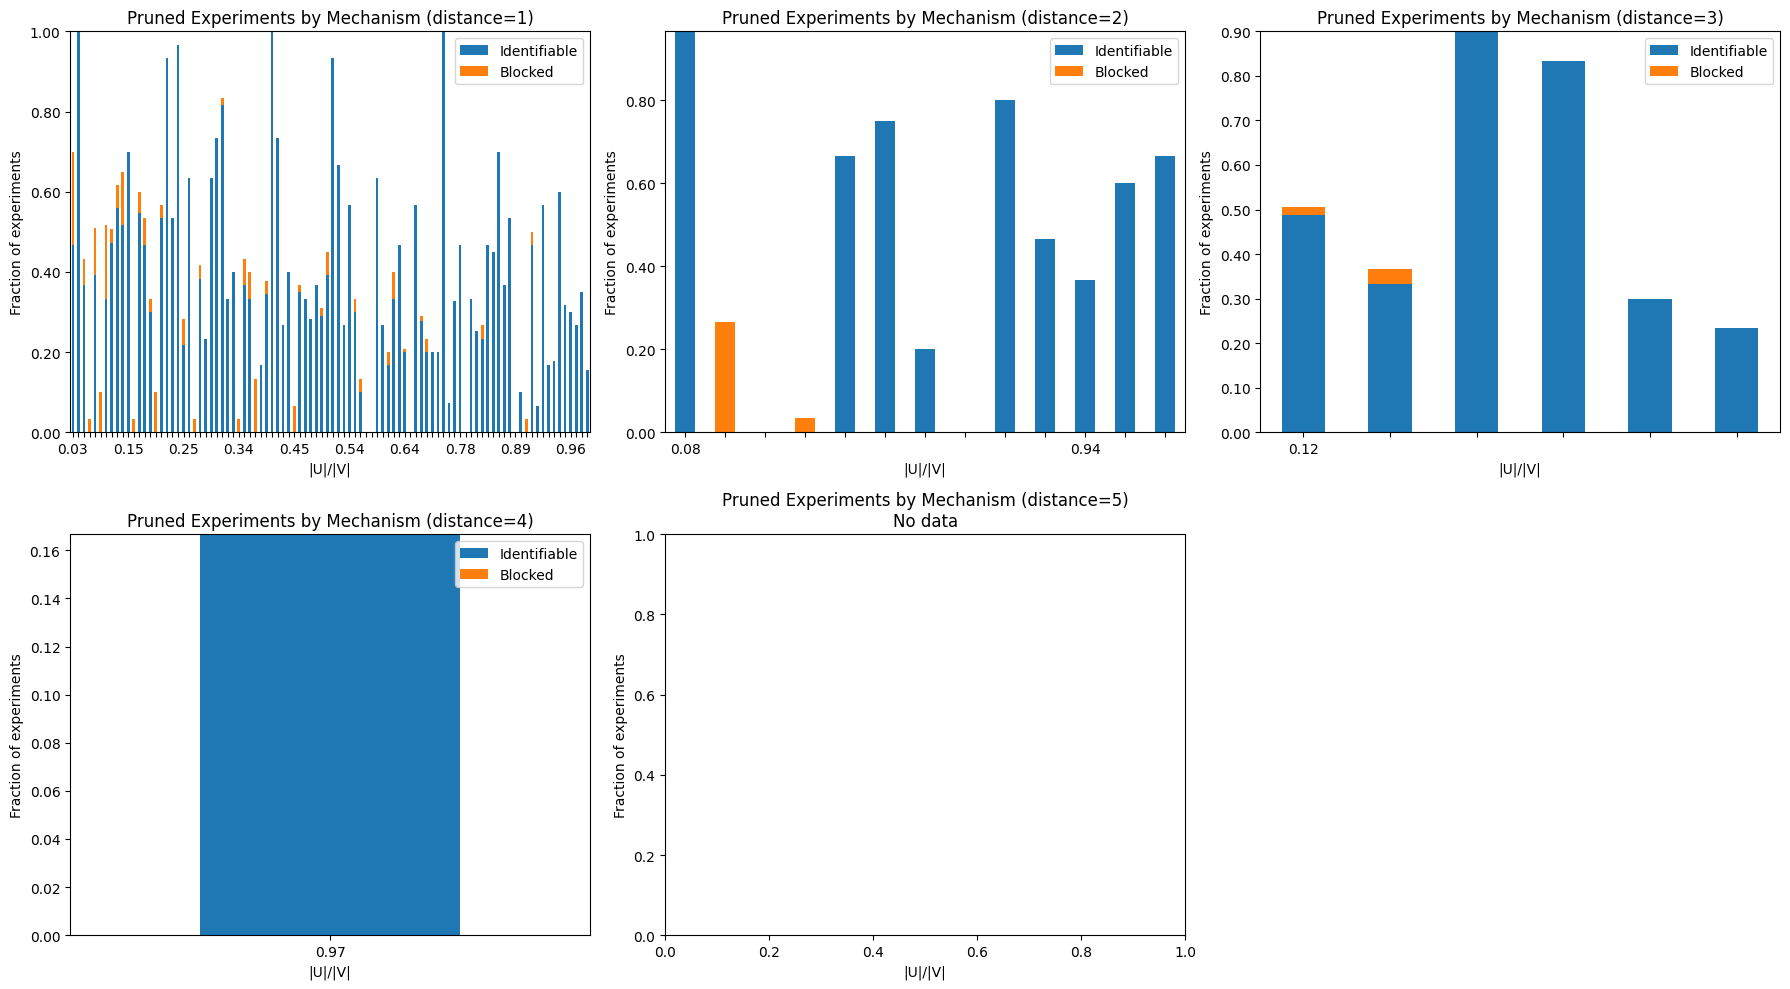

In [32]:
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np

n_rows=2
n_cols=3
# Build figure in this cell to ensure render
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
flat_axes = axes.flatten()

source_df = df if not df.empty else df_cf

distances = [1,2,3,4,5]

for idx, dist in enumerate(distances):
    ax = flat_axes[idx]

    mask = source_df["min_intervention_outcome_dist"] == dist
    d = source_df.loc[mask]

    if d.empty:
        ax.set_title(f"Pruned Experiments by Mechanism (distance={dist})\nNo data")
        ax.set_xlabel("|U|/|V|")
        ax.set_ylabel("Fraction of experiments")
        continue

    p = pd.DataFrame({
        "fraction_id": d["id_pruned"] / d["n_experiments"],
        "fraction_blocked": d["blocked_pruned"] / d["n_experiments"],
        "fraction_confounders": d["n_confounders"] / d["n_vars"],
    })

    p = p.groupby("fraction_confounders", as_index=True)[["fraction_id", "fraction_blocked"]].mean()
    p.index = p.index.round(2)

    p.plot(kind="bar", stacked=True, ax=ax)

    ax.set_xlabel("|U|/|V|")
    ax.set_ylabel("Fraction of experiments")
    ax.set_title(f"Pruned Experiments by Mechanism (distance={dist})")
    ax.legend(["Identifiable", "Blocked"])
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    xlabels = [f"{v:.2f}" if i % 10 == 0 else "" for i, v in enumerate(p.index)]
    ax.set_xticklabels(xlabels, rotation=0)

# hide unused panels
for j in range(len(distances), len(flat_axes)):
    flat_axes[j].set_visible(False)

fig.tight_layout()
plt.show()

## Different $R^*_\theta$

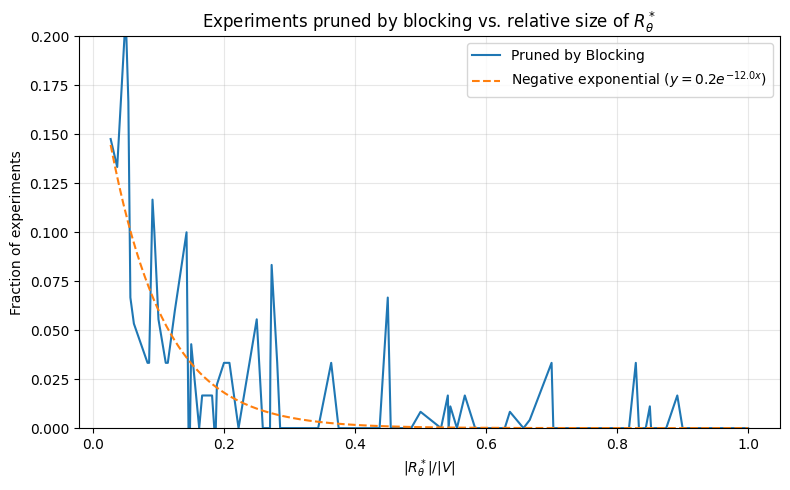

In [40]:
plot_df = (
    df.assign(
        r_star_frac=df["n_R_theta_star"] / df["n_vars"],
        fraction_id=df["id_pruned"] / df["n_experiments"],
        fraction_blocked=df["blocked_pruned"] / df["n_experiments"],
    )
    .groupby("r_star_frac", as_index=False)[["fraction_id", "fraction_blocked"]]
    .mean()
    .sort_values("r_star_frac")
)

plt.figure(figsize=(8, 5))
plt.plot(plot_df["r_star_frac"], plot_df["fraction_blocked"], label="Pruned by Blocking")
# plt.plot(plot_df["r_star_frac"], plot_df["fraction_id"], label="Pruned by ID")

# Negative exponential curve: y = a * exp(-b x)
x_exp = np.linspace(plot_df["r_star_frac"].min(), plot_df["r_star_frac"].max(), 300)
a, b = 0.2, 12.0
y_exp = a * np.exp(-b * x_exp)
plt.plot(x_exp, y_exp, linestyle="--", label=rf"Negative exponential ($y={a}e^{{-{b}x}}$)")

plt.xlabel(r"$|R^*_\theta|/|V|$")
plt.ylabel("Fraction of experiments")
plt.title(r"Experiments pruned by blocking vs. relative size of $R^*_\theta$")
plt.ylim(0, 0.2)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


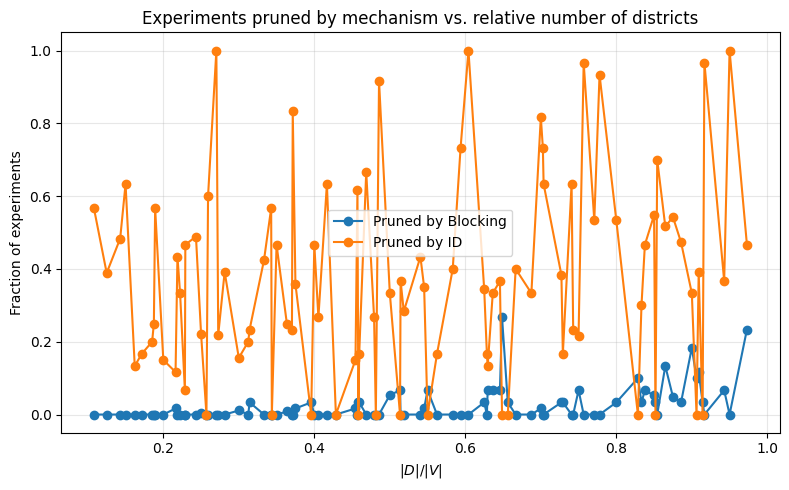

In [36]:
plot_df = (
    df.assign(
        districts_frac=df["n_districts"] / df["n_vars"],
        fraction_id=df["id_pruned"] / df["n_experiments"],
        fraction_blocked=df["blocked_pruned"] / df["n_experiments"],
    )
    .groupby("districts_frac", as_index=False)[["fraction_id", "fraction_blocked"]]
    .mean()
    .sort_values("districts_frac")
)

plt.figure(figsize=(8, 5))
plt.plot(plot_df["districts_frac"], plot_df["fraction_blocked"], marker="o", label="Pruned by Blocking")
plt.plot(plot_df["districts_frac"], plot_df["fraction_id"], marker="o", label="Pruned by ID")

plt.xlabel(r"$|D|/|V|$")
plt.ylabel("Fraction of experiments")
plt.title("Experiments pruned by mechanism vs. relative number of districts")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
